In [40]:
import numpy as np
from itertools import zip_longest
class t_avg():
    def __init__(self,total_distance,num_repeaters):
        self.rng= np.random.default_rng()
        self.total_distance=total_distance
        self.num_repeaters=num_repeaters
        self.node_dist=total_distance/(2*num_repeaters+2)
        self.tau = 60e-3    
        self.F_em_single = 0.96
        pem = 4 / 3 * (1 - self.F_em_single)
        self.w_em = 1 - pem
        self.w_ms = 0.99
        
        # --- make these instance attributes ---
        self.qfc_eff = 0.3
        self.det_eff = 0.9
        self.coll_eff = 1
        self.fib_loss = 0.2
        
        fiber_eff = np.power(10, -self.node_dist * self.fib_loss / 10)
        self.survive_prob = self.qfc_eff * self.det_eff * self.coll_eff * fiber_eff
        self.p=self.survive_prob**2/2
        self.DBSM_time = 119000/1e9
        self.BSM_time = 5000/1e9
        self.spin_echo_time = 36000/1e9 
        self.K=91
        self.photon_travel=self.node_dist*2/(2E5)
        self.init_time = 7220000/1e9
        self.retry_time = 75000/1e9  
        self.T_attempt=self.photon_travel+self.retry_time+self.BSM_time
        self.ctrl_msg_time=(self.total_distance-self.node_dist)*2/(2E5) #From last bsm node to left end node(control node) and back
        self.end_msg_time=(2*self.total_distance-self.node_dist)/(2E5) #From last bsm node to left end node(control node) and back to right end node 
        num_link=num_repeaters+1
        if num_link%2==0:
            self.n_odd=int(num_link/2)
            self.n_even=int(num_link/2)
        else:
            self.n_odd=int(num_repeaters/2+1)
            self.n_even=int(num_repeaters/2)
            
    def Pr_M_leq_k(self,k,n):
        return (1-(1-self.p)**k)**n

    def Pr_X_leq_k(self,k,n):
        return 1-(1-self.p)**k
    
    def E_M_cond_leq_K(self,n):
        sum=0
        for k in range(self.K+1):
            sum+=k*(self.Pr_M_leq_k(k,n)-self.Pr_M_leq_k(k-1,n))
        return sum/self.Pr_M_leq_k(self.K,n)

    def E_X_cond_leq_K(self,n):
        sum=0
        for k in range(self.K+1):
            sum+=k*(self.Pr_X_leq_k(k,n)-self.Pr_X_leq_k(k-1,n))
        return sum/self.Pr_X_leq_k(self.K,n) #Check later

    def Tavg(self):
        avg_waiting_odd=self.E_M_cond_leq_K(self.n_odd)-self.E_X_cond_leq_K(self.n_odd)+1+self.E_M_cond_leq_K(self.n_even)
        avg_waiting_even=self.E_M_cond_leq_K(self.n_even)-self.E_X_cond_leq_K(self.n_even)+1
        ctrl_msg_time=(self.total_distance/2-self.node_dist)*2/(2E5) #From 1st bsm node to centralized node and back
        end_msg_time=(self.total_distance-self.node_dist)/(2E5) #From 1st bsm node to centralized node and back to end node
        Tavg_odd=self.T_attempt*avg_waiting_odd+self.spin_echo_time*(avg_waiting_odd//5)+ctrl_msg_time
        Tavg_even=self.T_attempt*avg_waiting_odd+self.spin_echo_time*(avg_waiting_odd//5) #Incorrect since DBSM is performed immediately after pBSM succeeds
        print("ctrl_msg_time",ctrl_msg_time,"end_msg_time",end_msg_time)
        print("avg_waiting_odd",avg_waiting_odd,"avg_waiting_even",avg_waiting_even,"Tavg_odd",Tavg_odd,"Tavg_even",Tavg_even,"spin echo time",f"{self.spin_echo_time*(avg_waiting_odd//5):.9g}")
        return Tavg_odd,Tavg_even
    
    def cal_F_total(self):
        theta_final=1
        lamb=self.w_ms ** (self.num_repeaters)
        F_total=1/4*(1+self.w_em ** (2*self.num_repeaters+2)*(2*lamb*theta_final+lamb**2))
        return F_total

    
    def Favg_MC(self,MC_shots):
        success_cnt=0
        odd_success_cnt=0
        total_cnt=0
        total_time=0
        total_attempt=0
        Esigma_ls=[]
        avg_retries_ls=[]
        while success_cnt<MC_shots:
            total_cnt+=1
            all_odd_success,required_attempts_odd=self.pBSM_MC(self.n_odd)
            
            if all_odd_success:
                odd_success_cnt+=1
                max_attempt_odd=max(required_attempts_odd)
                total_attempt+=max_attempt_odd
                all_even_success,required_attempts_even=self.pBSM_MC(self.n_even)
                
                if all_even_success:
                    avg_retries_ls.append(np.mean(np.concatenate([np.asarray(required_attempts_even),
                       np.asarray(required_attempts_odd)]))-1)
                    max_attempt_even=max(required_attempts_even)
                    total_attempt+=max_attempt_even
                    waiting_even = [max_attempt_even- v +1 for v in required_attempts_even]
                    waiting_odd = [max_attempt_odd - v +1 +max_attempt_even for v in required_attempts_odd]
                    sum_deltaT_squared=self.cal_sum_deltaT_squared(required_attempts_even,required_attempts_odd)
                    Esigma_ls.append(np.exp(-1/2*(2/self.tau)**2*sum_deltaT_squared))                                
                    success_cnt+=1
                else:
                    total_attempt+=self.K
            else:
                total_attempt+=self.K
        Esigma=sum(Esigma_ls)/len(Esigma_ls)
        lamb=self.w_ms ** self.num_repeaters

        F_avg=1/4*(1+self.w_em ** (2*self.num_repeaters+2)*(2*lamb*Esigma+lamb**2))
        avg_retries=np.mean(avg_retries_ls)
        total_time=total_cnt*self.init_time+total_attempt*self.T_attempt
        rate=1/total_time*success_cnt
        print("total_time",total_time,"rate",rate)

        return F_avg,rate,success_cnt,total_cnt,avg_retries
    
    def ion_to_link(self,j):
        return int((j+1)//2)
        
    def cal_sum_deltaT_squared(self,required_attempts_even,required_attempts_odd):
        max_attempt_even=max(required_attempts_even)
        max_attempt_odd=max(required_attempts_odd)
        required_attempts = []
        for o, e in zip_longest(required_attempts_odd, required_attempts_even):
            required_attempts.append(o)
            if e is not None:
                required_attempts.append(e) 
            
        Y={} #T_attempt times
        Z={} #spin-echo times
        deltaT={}
        for j in range(1,2*self.num_repeaters+2+1):
            link_idx=self.ion_to_link(j)-1
            if j==1: #Left end node
                Y[j]=max_attempt_odd - required_attempts[link_idx] +1 +max_attempt_even
                Z[j]=(max_attempt_odd - required_attempts[link_idx] +1)//5+max_attempt_even//5
                deltaT[j]=self.ctrl_msg_time+self.end_msg_time
            elif j==2*self.num_repeaters+2: #Right end node
                if self.ion_to_link(j)%2==1:
                    Y[j]=max_attempt_odd - required_attempts[link_idx] +1 +max_attempt_even
                    Z[j]=(max_attempt_odd - required_attempts[link_idx] +1)//5+max_attempt_even//5
                    deltaT[j]=self.ctrl_msg_time+self.end_msg_time
                else:
                    Y[j]=max_attempt_even - required_attempts[link_idx] +1 
                    Z[j]=(max_attempt_even - required_attempts[link_idx] +1)//5
                    deltaT[j]=self.end_msg_time
            elif self.ion_to_link(j)%2==1:
                if j%2==1: #odd link, left ion
                    Y[j]=max_attempt_odd - required_attempts[link_idx] +1 +required_attempts[link_idx-1]
                    Z[j]=(max_attempt_odd - required_attempts[link_idx] +1)//5+required_attempts[link_idx-1]//5
                    deltaT[j]=self.ctrl_msg_time
                else: #odd link, right ion
                    Y[j]=max_attempt_odd - required_attempts[link_idx] +1 +required_attempts[link_idx+1]
                    Z[j]=(max_attempt_odd - required_attempts[link_idx] +1)//5+required_attempts[link_idx+1]//5
                    deltaT[j]=self.ctrl_msg_time
            elif self.ion_to_link(j)%2==0: #DBSM immediately after even link is successful
                Y[j]=1
                Z[j]=0
                deltaT[j]=0
        deltaT={k: Y[k]*self.T_attempt + Z[k]*self.spin_echo_time+ deltaT[k] for k in Y}
        return sum(value**2 for value in deltaT.values())                                
        
    def pBSM_MC(self,num_bsm):
        is_success=False
        required_attempts=self.rng.geometric(self.p,num_bsm)
        if all(v <= self.K for v in required_attempts):
            is_success=True
        return is_success,required_attempts

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MC_shots = 5000            # Monte‑Carlo samples for phase noise

results = []
distance_ls=[10, 50, 100]
for distance in distance_ls:
    for n in range(1,9):
        t_avg_instance=t_avg(total_distance=distance,num_repeaters=n) 
        print("survive prob",t_avg_instance.survive_prob,"pbsm prob",t_avg_instance.p,"success fraction per bsm",1-(1-t_avg_instance.p)**91)
        F_total,rate,success_cnt,total_cnt,avg_retries=t_avg_instance.Favg_MC(MC_shots)
        success_ratio = (success_cnt / total_cnt) if total_cnt else float("nan")
        sem = np.sqrt(F_total * (1 - F_total) / MC_SHOTS)
        results.append(dict(
            distance=distance,
            rate=rate,
            sem=sem,
            num_repeaters=n,
            fidelity=F_total,
            success_ratio=success_ratio,
            success_cnt=int(success_cnt),
            total_cnt=int(total_cnt),
            avg_retries=avg_retries
        ))
    
output_df = pd.DataFrame(results)
output_df.to_csv("100theo_fidelity_and_success.csv", index=False)

print("distance(km)  n  avg_retries   fidelity     rate    success_ratio   success_cnt  total_cnt")
for r in results:
    print(f"{r['distance']:>11}  {r['num_repeaters']:d}   {r['avg_retries']:.3f}         {r['fidelity']:.6f}    "
          f"{r['rate']:.6f}     {r['success_ratio']:.6f}      {r['success_cnt']:>6d}      {r['total_cnt']:>6d}")


# plt.figure(figsize=(8, 5))
# for dist in distance_ls:
#     subset = output_df[output_df["distance"] == dist]
#     plt.plot(subset["num_repeaters"], subset["fidelity"],
#              marker='o', label=f"{dist} km")

# plt.xlabel("Number of Repeaters")
# plt.ylabel("Theoretical Fidelity")
# plt.ylim(0, 1)
# plt.title("Theoretical Fidelity vs Number of Repeaters")
# plt.legend(title="Distance")
# plt.tight_layout()
# plt.savefig("theo_fidelity.png")
# plt.show()

# plt.figure(figsize=(8, 5))
# for dist in distance_ls:
#     subset = output_df[output_df["distance"] == dist]
#     plt.plot(subset["num_repeaters"], subset["rate"], marker='o', label=f"{dist} km")
# plt.xlabel("Number of Repeaters")
# plt.ylabel("Repeater Rate")
# #plt.ylim(0, 1)
# plt.title("Repeater Rate vs Number of Repeaters")
# plt.legend(title="Distance")
# plt.tight_layout()
# plt.savefig("theo_rate.png")
# plt.show()

survive prob 0.1660400497743168 pbsm prob 0.0137846490645288 success fraction per bsm 0.7172321683555025
total_time 158.37981499999998 rate 31.569679507454914
survive prob 0.17253591905039423 pbsm prob 0.014884321681282094 success fraction per bsm 0.7445311094155747
total_time 199.17408999999998 rate 25.103666847429807
survive prob 0.17587854125206753 pbsm prob 0.01546663063647761 success fraction per bsm 0.757913769966528
total_time 256.58034999999995 rate 19.48707295784732
survive prob 0.17791511877579352 pbsm prob 0.01582689474450236 success fraction per bsm 0.7658437018643354
total_time 321.02923 rate 15.574905749236605
survive prob 0.1792859216979639 pbsm prob 0.01607172085954422 success fraction per bsm 0.771085502638765
total_time 409.076105 rate 12.222664533290207
survive prob 0.18027152830607118 pbsm prob 0.016248911958903312 success fraction per bsm 0.7748066617406195
total_time 493.0468928571429 rate 10.141023242283604
survive prob 0.18101428737881486 pbsm prob 0.01638308611

In [41]:
import numpy as np
import pandas as pd
from tqdm import tqdm

MC_SHOTS = 5000

# Common settings
DISTANCES = [50]
REPEATERS = [1, 4, 8]

# def run_sweep(param_name, values, fixed_kwargs, filename, compute_init_loss=None):
#     """
#     Run a parameter sweep, store results in a CSV.
#     param_name: str — which parameter to vary
#     values: list — parameter values
#     fixed_kwargs: dict — fixed parameter values
#     filename: str — output CSV file name
#     compute_init_loss: callable (optional) — compute 'init_photon_loss' from the varied parameter
#     """
#     records = []

#     for dist in DISTANCES:
#         for n in REPEATERS:
#             for val in tqdm(values, desc=f"{param_name}: dist={dist}, rep={n}"):
#                 # Create instance
#                 obj = t_avg(total_distance=dist, num_repeaters=n)
                
#                 # Apply parameter change
#                 if param_name == "qfc_eff":
#                     obj.qfc_eff = val
#                     obj.survive_prob = val * obj.det_eff * obj.coll_eff * np.power(10, -obj.node_dist * obj.fib_loss / 10)
#                     obj.p = obj.survive_prob ** 2 / 2
#                 elif param_name == "tau":
#                     obj.tau = val
#                 elif param_name == "K":
#                     obj.K = val
#                 elif param_name == "fib_loss":
#                     obj.fib_loss = val
#                     fiber_eff = np.power(10, -obj.node_dist * obj.fib_loss / 10)
#                     obj.survive_prob = obj.qfc_eff * obj.det_eff * obj.coll_eff * fiber_eff
#                     obj.p = obj.survive_prob ** 2 / 2
#                 elif param_name == "F_em_single":
#                     obj.F_em_single = val
#                     pem = 4 / 3 * (1 - val)
#                     obj.w_em = 1 - pem
#                 elif param_name == "w_ms":
#                     obj.w_ms = val
#                 elif param_name == "coll_eff":
#                     obj.coll_eff = val
#                     obj.survive_prob = obj.qfc_eff * obj.det_eff * obj.coll_eff * np.power(10, -obj.node_dist * obj.fib_loss / 10)
#                     obj.p = obj.survive_prob ** 2 / 2
                
#                 # Run Monte Carlo
#                 F_total, rate, success_cnt, total_cnt, avg_retries = obj.Favg_MC(MC_SHOTS)
#                 sem = np.sqrt(F_total * (1 - F_total) / MC_SHOTS)
#                 success_ratio = success_cnt / total_cnt if total_cnt else np.nan
                
#                 init_loss = compute_init_loss(val) if compute_init_loss else np.nan

#                 records.append(dict(
#                     num_repeaters=n,
#                     distance=dist,
#                     init_photon_loss=init_loss,
#                     fidelity=F_total,
#                     sem=sem,
#                     rate=rate,
#                     mean_retries=avg_retries,
#                     num_success=success_cnt
#                 ))

#     df = pd.DataFrame(records)
#     df.to_csv(filename, index=False)
#     print(f"✅ Saved results to {filename}")
#     return df

def run_sweep(param_name, values, fixed_kwargs, filename, compute_init_loss=None):
    """
    Run a parameter sweep, store results in a CSV.
    param_name: str — which parameter to vary
    values: list — parameter values
    fixed_kwargs: dict — fixed parameter values
    filename: str — output CSV file name
    compute_init_loss: callable (optional) — compute 'init_photon_loss' from the varied parameter
    """
    records = []

    for dist in DISTANCES:
        for n in REPEATERS:
            for val in tqdm(values, desc=f"{param_name}: dist={dist}, rep={n}"):
                # Create instance
                obj = t_avg(total_distance=dist, num_repeaters=n)
                
                # Apply parameter change
                if param_name == "qfc_eff":
                    obj.qfc_eff = val
                    obj.survive_prob = val * obj.det_eff * obj.coll_eff * np.power(10, -obj.node_dist * obj.fib_loss / 10)
                    obj.p = obj.survive_prob ** 2 / 2
                elif param_name == "tau":
                    obj.tau = val
                elif param_name == "K":
                    obj.K = val
                elif param_name == "fib_loss":
                    obj.fib_loss = val
                    fiber_eff = np.power(10, -obj.node_dist * obj.fib_loss / 10)
                    obj.survive_prob = obj.qfc_eff * obj.det_eff * obj.coll_eff * fiber_eff
                    obj.p = obj.survive_prob ** 2 / 2
                elif param_name == "F_em_single":
                    obj.F_em_single = val
                    pem = 4 / 3 * (1 - val)
                    obj.w_em = 1 - pem
                elif param_name == "w_ms":
                    obj.w_ms = val
                elif param_name == "coll_eff":
                    obj.coll_eff = val
                    obj.survive_prob = obj.qfc_eff * obj.det_eff * obj.coll_eff * np.power(10, -obj.node_dist * obj.fib_loss / 10)
                    obj.p = obj.survive_prob ** 2 / 2
                
                # Run Monte Carlo
                F_total, rate, success_cnt, total_cnt, avg_retries = obj.Favg_MC(MC_SHOTS)
                sem = np.sqrt(F_total * (1 - F_total) / MC_SHOTS)
                success_ratio = success_cnt / total_cnt if total_cnt else np.nan
                
                # Store all inputs + outputs
                record = dict(
                    num_repeaters=n,
                    distance=dist,
                    init_photon_loss=compute_init_loss(val) if compute_init_loss else np.nan,
                    fidelity=F_total,
                    sem=sem,
                    rate=rate,
                    mean_retries=avg_retries,
                    num_success=success_cnt,
                    # Preserve all parameter values exactly
                    qfc_eff=getattr(obj, "qfc_eff", np.nan),
                    coll_eff=getattr(obj, "coll_eff", np.nan),
                    fib_loss=getattr(obj, "fib_loss", np.nan),
                    F_em_single=getattr(obj, "F_em_single", np.nan),
                    w_ms=getattr(obj, "w_ms", np.nan),
                    tau=getattr(obj, "tau", np.nan),
                    K=getattr(obj, "K", np.nan)
                )
                records.append(record)

    df = pd.DataFrame(records)

    # Preserve input decimals exactly
    input_cols = ["init_photon_loss", "qfc_eff", "coll_eff", "fib_loss", "F_em_single", "w_ms", "tau", "K"]
    for col in input_cols:
        if col in df.columns:
            df[col] = df[col].map(lambda x: f"{x:g}" if not pd.isna(x) else x)

    # Save CSV with high precision for computed outputs
    df.to_csv(filename, index=False, float_format="%.10g")
    print(f"✅ Saved results to {filename}")
    return df

if __name__ == "__main__":
    # 1️⃣ QFC efficiency sweep
    # qfc_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    # run_sweep("qfc_eff", qfc_values, {}, "qfc_eff_sweep.csv", compute_init_loss=lambda q: 1 - q)

    # 2️⃣ Coherence time sweep
    # tau_values = [60e-3, 100e-3, 150e-3, 200e-3, 250e-3]
    # run_sweep("tau", tau_values, {}, "coherence_time_sweep.csv")

    # 3️⃣ Retry threshold sweep
    K_values = [31, 61, 91, 121]
    distances = [20, 40, 80, 120]
    records = []
    for dist in distances:
        for K in K_values:
            obj = t_avg(total_distance=dist, num_repeaters=1)
            obj.K = K
            F_total, rate, success_cnt, total_cnt, avg_retries = obj.Favg_MC(MC_SHOTS)
            sem = np.sqrt(F_total * (1 - F_total) / MC_SHOTS)
            success_ratio = success_cnt / total_cnt if total_cnt else np.nan
            records.append(dict(
                num_repeaters=1,
                distance=dist,
                retries=K,
                fidelity=F_total,
                sem=sem,
                rate=rate,
                mean_retries=avg_retries,
                num_success=success_cnt
            ))
    pd.DataFrame(records).to_csv("ceretry_threshold_sweep.csv", index=False)

    # # 4️⃣ Fiber loss sweep
    # fib_losses = [0.3, 0.2, 0.1]
    # run_sweep("fib_loss", fib_losses, {}, "photon_loss_sweep.csv")

    # 5️⃣ Emission fidelity sweep
    # F_em_single_values = [0.96, 0.97, 0.98, 0.99, 1.0]
    # run_sweep("F_em_single", F_em_single_values, {}, "emission_fidelity_sweep.csv")

    # # 6️⃣ MS depolarization sweep
    # ms_dep_probs = [0.1, 0.09, 0.08, 0.07, 0.06, 0.05]
    # run_sweep("w_ms", [1 - x for x in ms_dep_probs], {}, "ms_depolarization_sweep.csv")

    # # 7️⃣ Collection efficiency sweep
    # coll_eff_values = [0.6, 0.7, 0.8, 0.9]
    # run_sweep("coll_eff", coll_eff_values, {}, "collection_efficiency_sweep.csv")


total_time 216.20637000000002 rate 23.12605313155204
total_time 129.98384000000001 rate 38.466320121024275
total_time 106.50348 rate 46.946822770485994
total_time 100.30353000000001 rate 49.84869425831772
total_time 491.01018 rate 10.18308826102139
total_time 265.59776 rate 18.825459973758814
total_time 209.63317999999998 rate 23.85118615287905
total_time 188.71256000000002 rate 26.495321774025
total_time 3113.2947000000004 rate 1.6060156463825925
total_time 1502.2227400000002 rate 3.328401219648692
total_time 1046.50754 rate 4.777796440912408
total_time 874.17952 rate 5.7196489801088
total_time 20568.078739999997 rate 0.24309514093196247
total_time 9133.53104 rate 0.5474334053393659
total_time 6272.116219999999 rate 0.7971791058425255
total_time 4799.8636 rate 1.0416962682022881


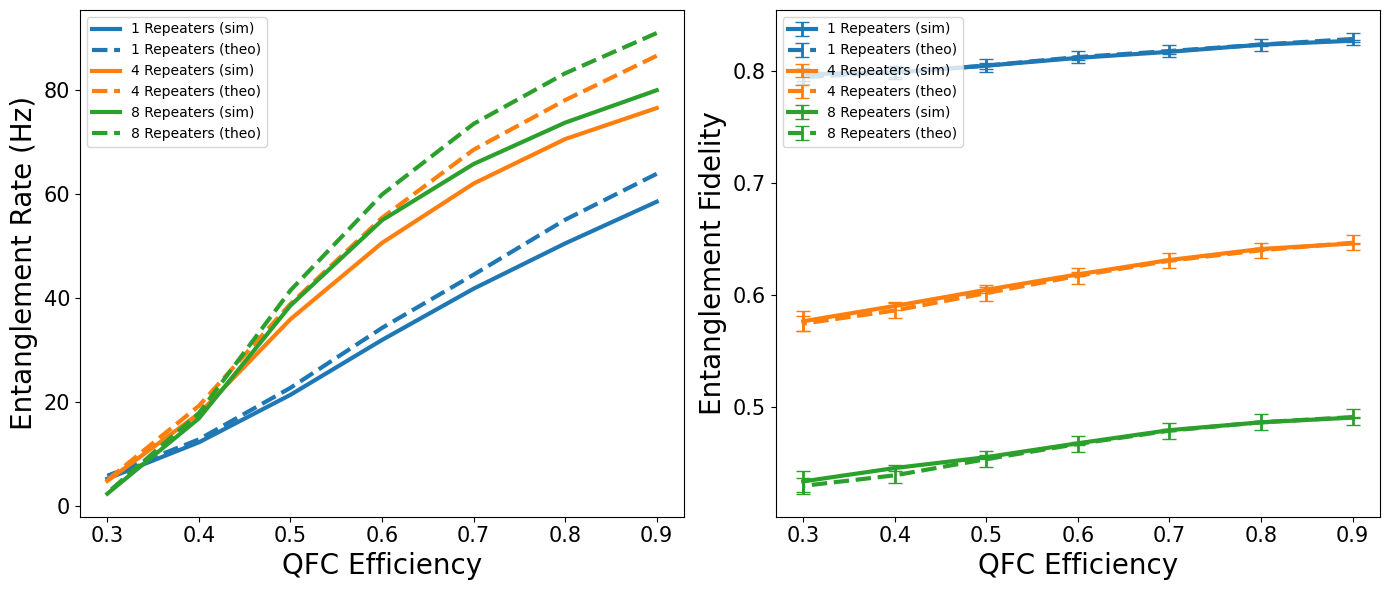

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15) 
# Load both datasets
df_main = pd.read_csv("results/rate/agg_qfc.csv")   # Replace with your main CSV
df_alt = pd.read_csv("qfc_eff_sweep.csv")     # Replace with your alternative CSV

# Filter for specific repeater counts if needed
repeaters = [1, 4, 8]

# Line styles
alt_linestyles = ['--', '--', '--']  # Alternative CSV
colors = ['C0', 'C1', 'C2']        # Same color per repeater count

# Create side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ===== Rate vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = 1 - subset_main["init_photon_loss"]
    y_main = subset_main["rate"]
    
    x_alt = 1 - subset_alt["init_photon_loss"]
    y_alt = subset_alt["rate"]

    # Solid line for main CSV
    ax[0].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")
    
    # Dotted/dashed line for alt CSV
    ax[0].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")

ax[0].set_xlabel("QFC Efficiency")
ax[0].set_ylabel("Entanglement Rate (Hz)")
# ax[0].set_title("Rate vs Init Photon Loss")
ax[0].legend()
ax[0].legend(loc='upper left')
# ax[0].grid(True)

# ===== Fidelity vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = 1 - subset_main["init_photon_loss"]
    y_main = subset_main["fidelity"]
    yerr_main = subset_main.get("sem", None)

    x_alt = 1 - subset_alt["init_photon_loss"]
    y_alt = subset_alt["fidelity"]
    yerr_alt = subset_alt.get("sem", None)

    # Main CSV with solid line
    if yerr_main is not None:
        ax[1].errorbar(x_main, y_main, yerr=yerr_main, color=colors[i], linestyle='-',
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (sim)")
    else:
        ax[1].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")

    # Alt CSV with dotted/dashed line
    if yerr_alt is not None:
        ax[1].errorbar(x_alt, y_alt, yerr=yerr_alt, color=colors[i], linestyle=alt_linestyles[i],
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (theo)")
    else:
        ax[1].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")

ax[1].set_xlabel("QFC Efficiency")
ax[1].set_ylabel("Entanglement Fidelity")
# ax[1].set_title("Fidelity vs Init Photon Loss")
ax[1].legend()
ax[1].legend(loc='upper left')
# ax[1].grid(True)

plt.tight_layout()
plt.show()


In [28]:
import pandas as pd

# Load alt CSV
df_alt = pd.read_csv("photon_loss_sweep.csv")

# Rename columns to match main CSV
df_alt = df_alt.rename(columns={"fib_loss": "photon_loss"})

# Reorder so that for each photon_loss, repeaters vary like main CSV
df_alt_sorted = df_alt.sort_values(by=["photon_loss", "num_repeaters"]).reset_index(drop=True)

# Keep only the relevant columns to match main CSV
df_alt_sorted = df_alt_sorted[["photon_loss", "num_repeaters", "fidelity", "sem", "rate"]]

# Overwrite the same CSV file
df_alt_sorted.to_csv("photon_loss_sweep.csv", index=False)


In [15]:
import pandas as pd

# === Load your QFC "alt" CSV ===
df_alt = pd.read_csv("qfc_eff_sweep.csv")

# Rename the loss column for consistency with the main CSV

# Sort so that for each photon_loss, repeaters vary (1 → 4 → 8)
df_alt_sorted = df_alt.sort_values(by=["init_photon_loss", "num_repeaters"]).reset_index(drop=True)

# Keep and reorder only the relevant columns to match your main CSV
df_alt_sorted = df_alt_sorted[["init_photon_loss", "num_repeaters", "fidelity", "sem", "rate"]]

# Save back with the same filename (overwrite)
df_alt_sorted.to_csv("qfc_eff_sweep.csv", index=False)

# print("✅ photon_loss_sweep.csv reordered and saved successfully!")


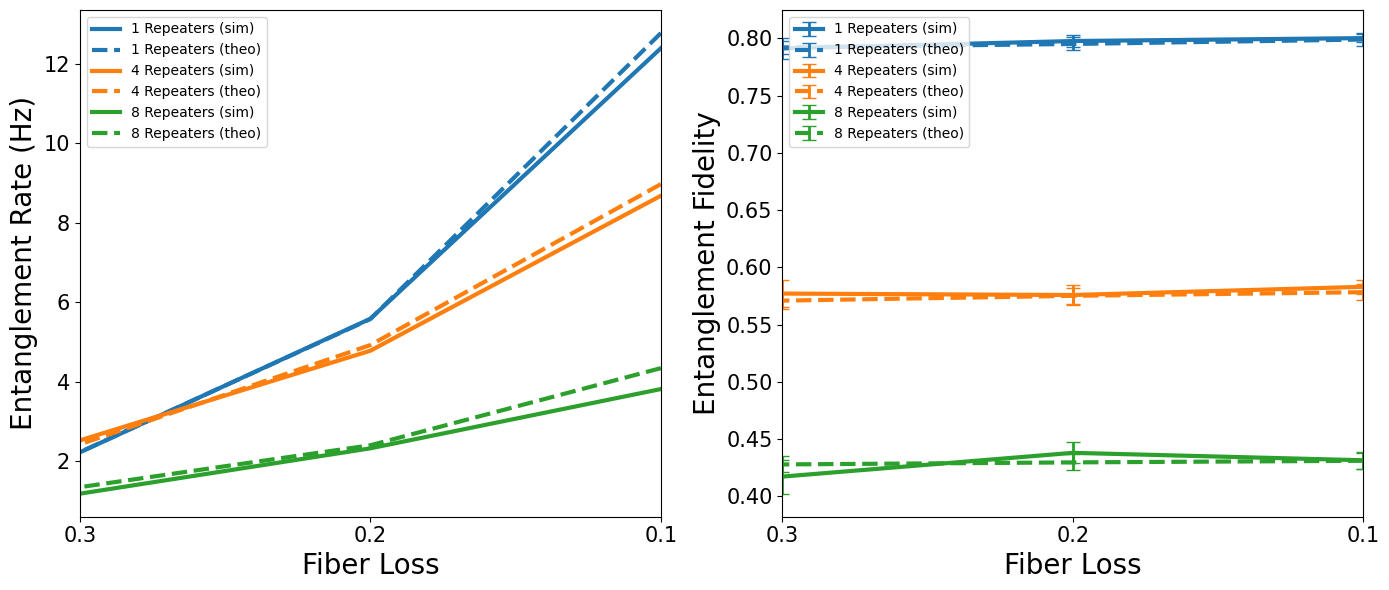

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15) 
# Load both datasets
df_main = pd.read_csv("results/rate/agg_fib_loss.csv")   # Replace with your main CSV
df_alt = pd.read_csv("photon_loss_sweep.csv")     # Replace with your alternative CSV

# Filter for specific repeater counts if needed
repeaters = [1, 4, 8]

# Line styles
alt_linestyles = ['--', '--', '--']  # Alternative CSV
colors = ['C0', 'C1', 'C2']        # Same color per repeater count

# Create side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ===== Rate vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = subset_main["photon_loss"]
    y_main = subset_main["rate"]
    
    x_alt = subset_alt["photon_loss"]
    y_alt = subset_alt["rate"]

    # Solid line for main CSV
    ax[0].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")
    
    # Dotted/dashed line for alt CSV
    ax[0].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
ax[0].set_xlim(0.3, 0.1)
ax[0].set_xticks([0.1, 0.2, 0.3])
ax[0].set_xlabel("Fiber Loss")
ax[0].set_ylabel("Entanglement Rate (Hz)")
# ax[0].set_title("Rate vs Init Photon Loss")
ax[0].legend()
ax[0].legend(loc='upper left')
# ax[0].grid(True)
# ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))

# ===== Fidelity vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = subset_main["photon_loss"]
    y_main = subset_main["fidelity"]
    yerr_main = subset_main.get("sem", None)

    x_alt = subset_alt["photon_loss"]
    y_alt = subset_alt["fidelity"]
    yerr_alt = subset_alt.get("sem", None)

    # Main CSV with solid line
    if yerr_main is not None:
        ax[1].errorbar(x_main, y_main, yerr=yerr_main, color=colors[i], linestyle='-',
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (sim)")
    else:
        ax[1].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")

    # Alt CSV with dotted/dashed line
    if yerr_alt is not None:
        ax[1].errorbar(x_alt, y_alt, yerr=yerr_alt, color=colors[i], linestyle=alt_linestyles[i],
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (theo)")
    else:
        ax[1].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
ax[1].set_xlim(0.3, 0.1)
ax[1].set_xticks([0.1, 0.2, 0.3])
ax[1].set_xlabel("Fiber Loss")
ax[1].set_ylabel("Entanglement Fidelity")
# ax[1].set_title("Fidelity vs Init Photon Loss")
ax[1].legend()
ax[1].legend(loc='upper left')
# ax[1].grid(True)
# ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))

plt.tight_layout()
plt.show()


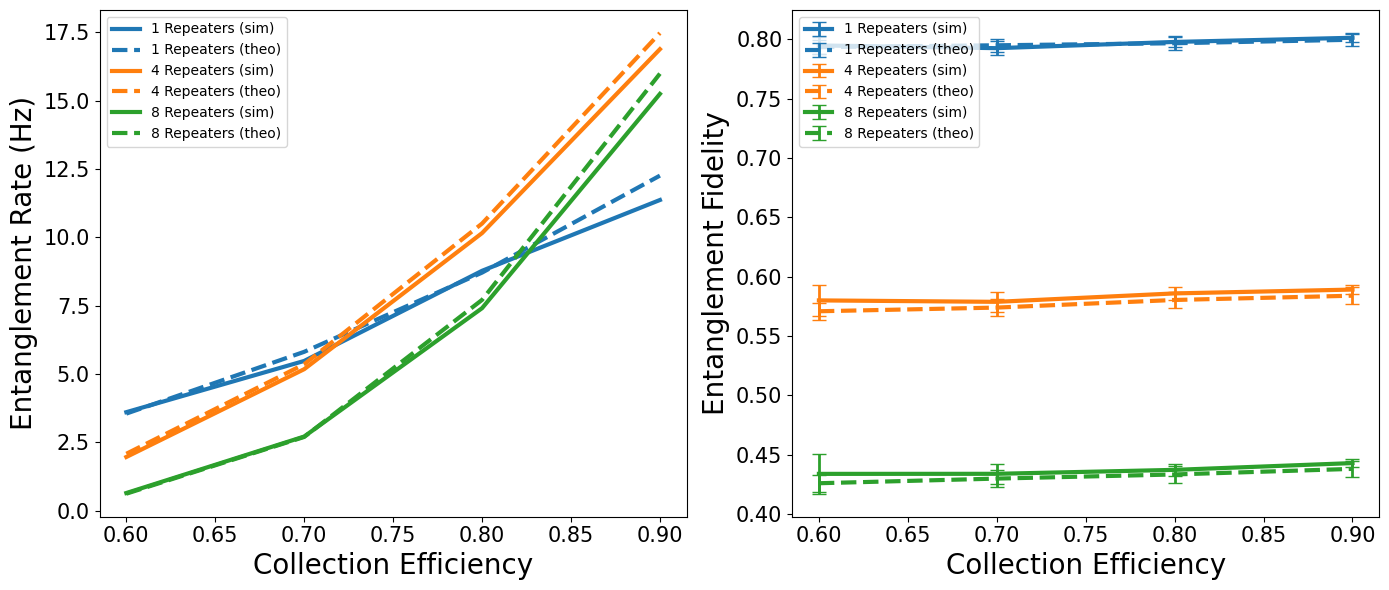

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Load both datasets
df_main = pd.read_csv("results/rate/agg_coll_eff.csv")   # Replace with your main CSV
df_alt = pd.read_csv("collection_efficiency_sweep.csv")     # Replace with your alternative CSV

# Filter for specific repeater counts if needed
repeaters = [1, 4, 8]
# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15) 
# Line styles
alt_linestyles = ['--', '--', '--']  # Alternative CSV
colors = ['C0', 'C1', 'C2']        # Same color per repeater count

# Create side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ===== Rate vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = subset_main["collection_efficiency"]
    y_main = subset_main["rate"]
    
    x_alt = subset_alt["coll_eff"]
    y_alt = subset_alt["rate"]

    # Solid line for main CSV
    ax[0].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")
    
    # Dotted/dashed line for alt CSV
    ax[0].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
# ax[0].set_xlim(0.3, 0.1)
ax[0].set_xlabel("Collection Efficiency")
ax[0].set_ylabel("Entanglement Rate (Hz)")
# ax[0].set_title("Rate vs Init Photon Loss")
ax[0].legend()
ax[0].legend(loc='upper left')
# ax[0].grid(True)
# ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))

# ===== Fidelity vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = subset_main["collection_efficiency"]
    y_main = subset_main["fidelity"]
    yerr_main = subset_main.get("sem", None)

    x_alt = subset_alt["coll_eff"]
    y_alt = subset_alt["fidelity"]
    yerr_alt = subset_alt.get("sem", None)

    # Main CSV with solid line
    if yerr_main is not None:
        ax[1].errorbar(x_main, y_main, yerr=yerr_main, color=colors[i], linestyle='-',
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (sim)")
    else:
        ax[1].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")

    # Alt CSV with dotted/dashed line
    if yerr_alt is not None:
        ax[1].errorbar(x_alt, y_alt, yerr=yerr_alt, color=colors[i], linestyle=alt_linestyles[i],
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (theo)")
    else:
        ax[1].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
# ax[1].set_xlim(0.3, 0.1)
ax[1].set_xlabel("Collection Efficiency")
ax[1].set_ylabel("Entanglement Fidelity")
# ax[1].set_title("Fidelity vs Init Photon Loss")
ax[1].legend()
ax[1].legend(loc='upper left')
# ax[1].grid(True)
# ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))

plt.tight_layout()
plt.savefig('theo_oneg_coll_eff.pdf', format='pdf')
plt.show()


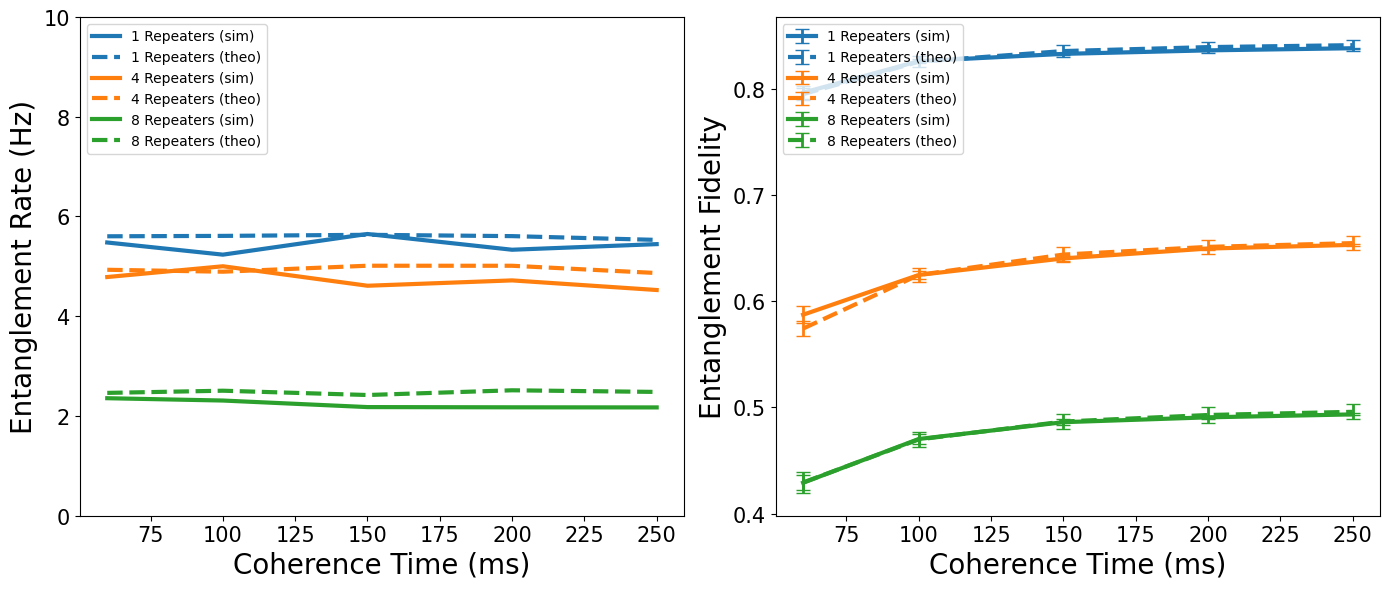

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Load both datasets
df_main = pd.read_csv("results/fidelity/agg_ct.csv")   # Replace with your main CSV
df_alt = pd.read_csv("coherence_time_sweep.csv")     # Replace with your alternative CSV

# Filter for specific repeater counts if needed
repeaters = [1, 4, 8]
# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15) 
# Line styles
alt_linestyles = ['--', '--', '--']  # Alternative CSV
colors = ['C0', 'C1', 'C2']        # Same color per repeater count

# Create side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ===== Rate vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = subset_main["coherence_time"]/1e6
    y_main = subset_main["rate"]
    
    x_alt = subset_alt["tau"]*1e3
    y_alt = subset_alt["rate"]

    # Solid line for main CSV
    ax[0].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")
    
    # Dotted/dashed line for alt CSV
    ax[0].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
ax[0].set_ylim(0, 10)
ax[0].set_xlabel("Coherence Time (ms)")
ax[0].set_ylabel("Entanglement Rate (Hz)")
# ax[0].set_title("Rate vs Init Photon Loss")
ax[0].legend()
ax[0].legend(loc='upper left')
# ax[0].grid(True)
# ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))

# ===== Fidelity vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = subset_main["coherence_time"]/1e6
    y_main = subset_main["fidelity"]
    yerr_main = subset_main.get("sem", None)

    x_alt = subset_alt["tau"]*1e3
    y_alt = subset_alt["fidelity"]
    yerr_alt = subset_alt.get("sem", None)

    # Main CSV with solid line
    if yerr_main is not None:
        ax[1].errorbar(x_main, y_main, yerr=yerr_main, color=colors[i], linestyle='-',
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (sim)")
    else:
        ax[1].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")

    # Alt CSV with dotted/dashed line
    if yerr_alt is not None:
        ax[1].errorbar(x_alt, y_alt, yerr=yerr_alt, color=colors[i], linestyle=alt_linestyles[i],
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (theo)")
    else:
        ax[1].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
# ax[1].set_ylim(0, 6)
ax[1].set_xlabel("Coherence Time (ms)")
ax[1].set_ylabel("Entanglement Fidelity")
# ax[1].set_title("Fidelity vs Init Photon Loss")
ax[1].legend()
ax[1].legend(loc='upper left')
# ax[1].grid(True)
# ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))
plt.savefig('coherence_time.pdf', format='pdf')

plt.tight_layout()
plt.show()


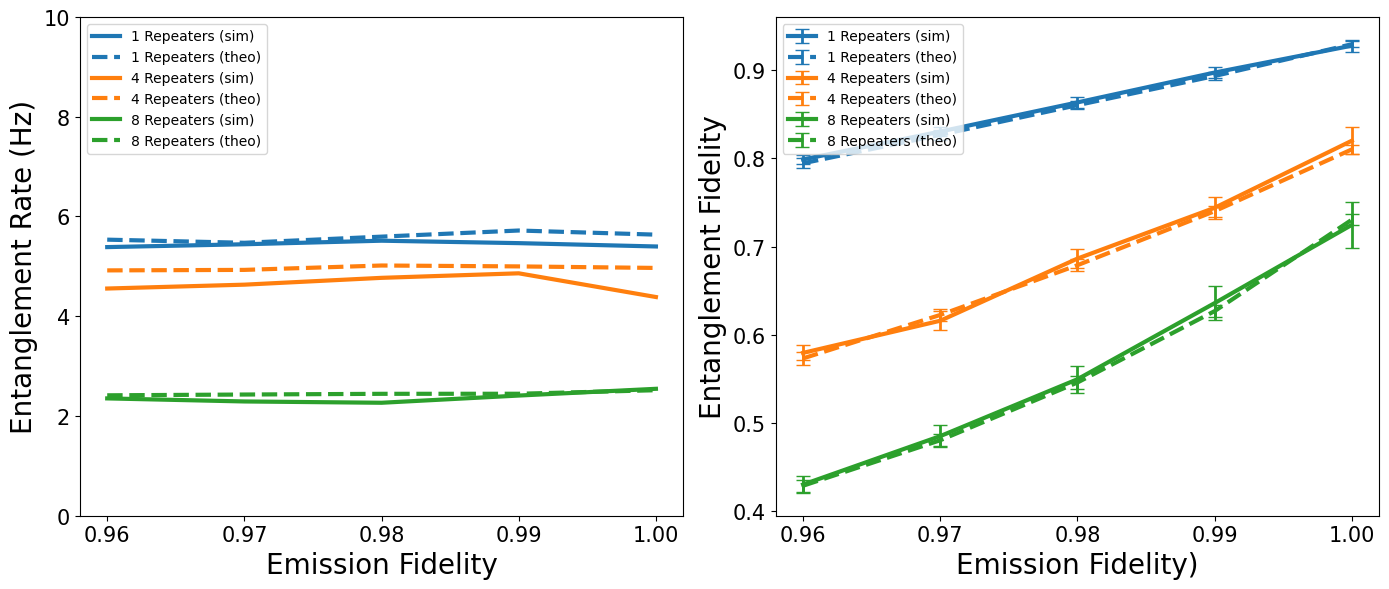

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Load both datasets
df_main = pd.read_csv("results/fidelity/agg_em_fid.csv")   # Replace with your main CSV
df_alt = pd.read_csv("emission_fidelity_sweep.csv")     # Replace with your alternative CSV

# Filter for specific repeater counts if needed
repeaters = [1, 4, 8]
# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15) 
# Line styles
alt_linestyles = ['--', '--', '--']  # Alternative CSV
colors = ['C0', 'C1', 'C2']        # Same color per repeater count

# Create side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ===== Rate vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = subset_main["emission_fidelity"]
    y_main = subset_main["rate"]
    
    x_alt = subset_alt["F_em_single"]
    y_alt = subset_alt["rate"]

    # Solid line for main CSV
    ax[0].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")
    
    # Dotted/dashed line for alt CSV
    ax[0].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
ax[0].set_ylim(0, 10)
ax[0].set_xticks([0.96, 0.97, 0.98, 0.99, 1])
ax[0].set_xlabel("Emission Fidelity")
ax[0].set_ylabel("Entanglement Rate (Hz)")
# ax[0].set_title("Rate vs Init Photon Loss")
ax[0].legend()
ax[0].legend(loc='upper left')
# ax[0].grid(True)
# ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))

# ===== Fidelity vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = subset_main["emission_fidelity"]
    y_main = subset_main["fidelity"]
    yerr_main = subset_main.get("sem", None)

    x_alt = subset_alt["F_em_single"]
    y_alt = subset_alt["fidelity"]
    yerr_alt = subset_alt.get("sem", None)

    # Main CSV with solid line
    if yerr_main is not None:
        ax[1].errorbar(x_main, y_main, yerr=yerr_main, color=colors[i], linestyle='-',
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (sim)")
    else:
        ax[1].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")

    # Alt CSV with dotted/dashed line
    if yerr_alt is not None:
        ax[1].errorbar(x_alt, y_alt, yerr=yerr_alt, color=colors[i], linestyle=alt_linestyles[i],
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (theo)")
    else:
        ax[1].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
# ax[1].set_ylim(0, 6)
ax[1].set_xticks([0.96, 0.97, 0.98, 0.99, 1])
ax[1].set_xlabel("Emission Fidelity)")
ax[1].set_ylabel("Entanglement Fidelity")
# ax[1].set_title("Fidelity vs Init Photon Loss")
ax[1].legend()
ax[1].legend(loc='upper left')
# ax[1].grid(True)
# ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))

plt.tight_layout()
plt.show()


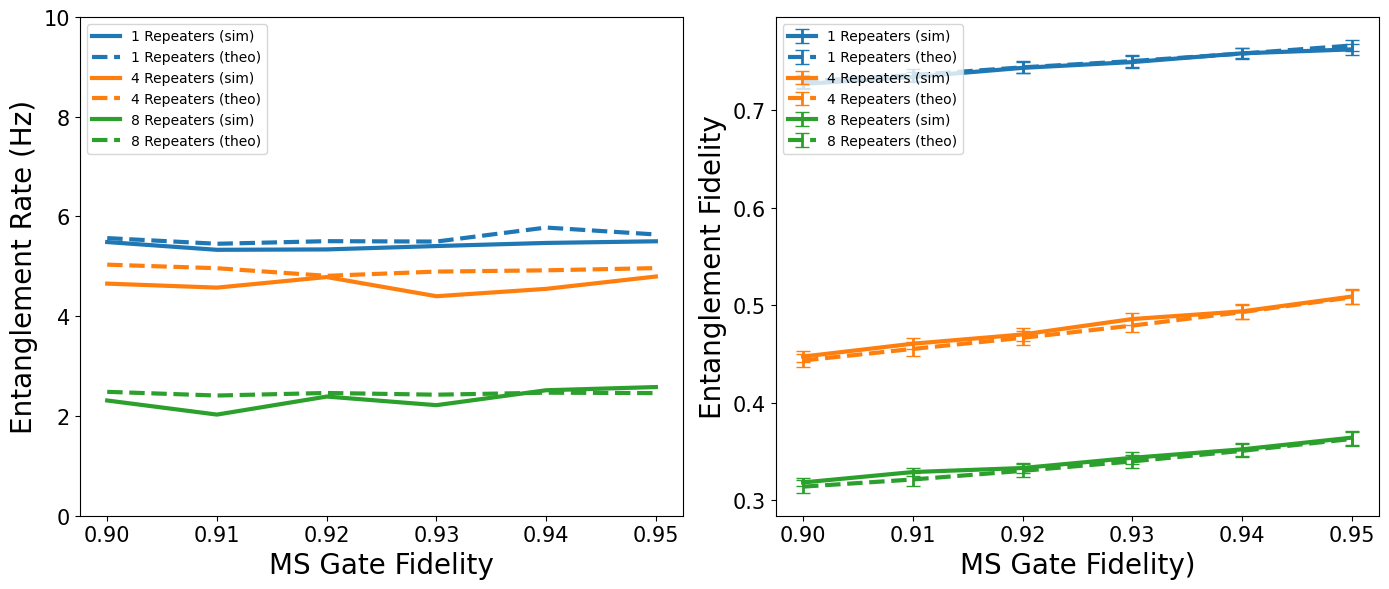

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Load both datasets
df_main = pd.read_csv("results/fidelity/agg_ms_fid.csv")   # Replace with your main CSV
df_alt = pd.read_csv("ms_depolarization_sweep.csv")     # Replace with your alternative CSV

# Filter for specific repeater counts if needed
repeaters = [1, 4, 8]
# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15) 
# Line styles
alt_linestyles = ['--', '--', '--']  # Alternative CSV
colors = ['C0', 'C1', 'C2']        # Same color per repeater count

# Create side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ===== Rate vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = 1 - subset_main["ms_depolar_prob"]
    y_main = subset_main["rate"]
    
    x_alt = subset_alt["w_ms"]
    y_alt = subset_alt["rate"]

    # Solid line for main CSV
    ax[0].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")
    
    # Dotted/dashed line for alt CSV
    ax[0].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
ax[0].set_ylim(0, 10)
# ax[0].set_xticks([0.96, 0.97, 0.98, 0.99, 1])
ax[0].set_xlabel("MS Gate Fidelity")
ax[0].set_ylabel("Entanglement Rate (Hz)")
# ax[0].set_title("Rate vs Init Photon Loss")
ax[0].legend()
ax[0].legend(loc='upper left')
# ax[0].grid(True)
# ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))

# ===== Fidelity vs Init Photon Loss =====
for i, rep in enumerate(repeaters):
    subset_main = df_main[df_main["num_repeaters"] == rep]
    subset_alt = df_alt[df_alt["num_repeaters"] == rep]

    x_main = 1 - subset_main["ms_depolar_prob"]
    y_main = subset_main["fidelity"]
    yerr_main = subset_main.get("sem", None)

    x_alt = subset_alt["w_ms"]
    y_alt = subset_alt["fidelity"]
    yerr_alt = subset_alt.get("sem", None)

    # Main CSV with solid line
    if yerr_main is not None:
        ax[1].errorbar(x_main, y_main, yerr=yerr_main, color=colors[i], linestyle='-',
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (sim)")
    else:
        ax[1].plot(x_main, y_main, color=colors[i], linestyle='-', label=f"{rep} Repeaters (sim)")

    # Alt CSV with dotted/dashed line
    if yerr_alt is not None:
        ax[1].errorbar(x_alt, y_alt, yerr=yerr_alt, color=colors[i], linestyle=alt_linestyles[i],
                       capsize=5, elinewidth=2, label=f"{rep} Repeaters (theo)")
    else:
        ax[1].plot(x_alt, y_alt, color=colors[i], linestyle=alt_linestyles[i], label=f"{rep} Repeaters (theo)")
# ax[1].set_ylim(0, 6)
# ax[1].set_xticks([0.96, 0.97, 0.98, 0.99, 1])
ax[1].set_xlabel("MS Gate Fidelity")
ax[1].set_ylabel("Entanglement Fidelity")
# ax[1].set_title("Fidelity vs Init Photon Loss")
ax[1].legend()
ax[1].legend(loc='upper left')
# ax[1].grid(True)
# ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.1f}"))

plt.tight_layout()
plt.show()


In [22]:
import pandas as pd

# Load CSV
df = pd.read_csv("retry_threshold_sweep.csv")

# Map retries to nearest standard value
def round_retries(x):
    if x <= 45:
        return 30
    elif x <= 75:
        return 60
    elif x <= 105:
        return 90
    else:
        return 120

df['retries'] = df['retries'].apply(round_retries)

# Save back to the same CSV
df.to_csv("retry_threshold_sweep.csv", index=False)


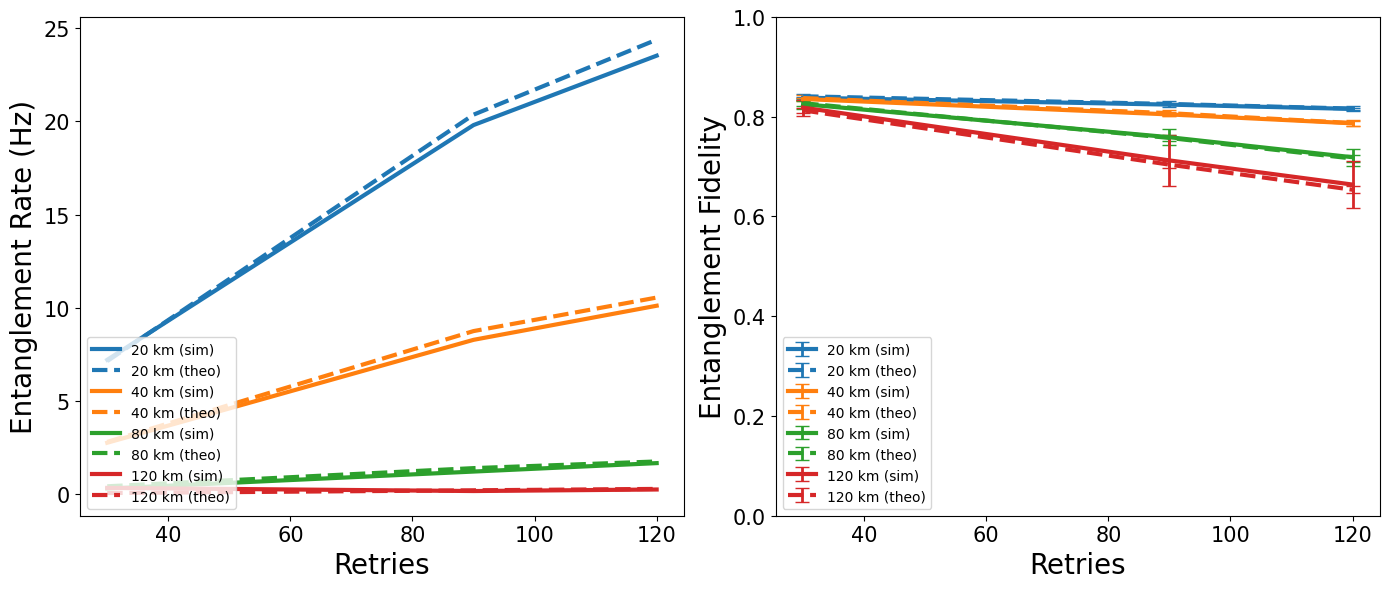

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# Load both datasets
df_sim = pd.read_csv("results/retries/results_by_distance_retries.csv")       # Simulation CSV
df_theo = pd.read_csv("retry_threshold_sweep.csv")  # Theoretical CSV

# Filter for specific retries if needed
retries_to_plot = [30, 90, 120]

# Set global plot formatting
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3.0)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

# Line styles
alt_linestyle = '--'  # Dotted/dashed line for theoretical
colors = ['C0', 'C1', 'C2', 'C3']  # One color per distance

# Distances
distances = [20, 40, 80, 120]

# Create side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ===== Rate vs Retries =====
for i, dist in enumerate(distances):
    subset_sim = df_sim[(df_sim["distance"] == dist) & (df_sim["retries"].isin(retries_to_plot))]
    subset_theo = df_theo[(df_theo["distance"] == dist) & (df_theo["retries"].isin(retries_to_plot))]

    # Solid line for sim
    ax[0].plot(subset_sim["retries"], subset_sim["rate"], color=colors[i], linestyle='-', label=f"{dist} km (sim)")
    
    # Dotted line for theo
    ax[0].plot(subset_theo["retries"], subset_theo["rate"], color=colors[i], linestyle=alt_linestyle, label=f"{dist} km (theo)")

ax[0].set_xlabel("Retries")
ax[0].set_ylabel("Entanglement Rate (Hz)")
ax[0].legend(loc='lower left')
# ax[0].set_title("Rate vs Retries")

# ===== Fidelity vs Retries =====
for i, dist in enumerate(distances):
    subset_sim = df_sim[(df_sim["distance"] == dist) & (df_sim["retries"].isin(retries_to_plot))]
    subset_theo = df_theo[(df_theo["distance"] == dist) & (df_theo["retries"].isin(retries_to_plot))]

    # Error bars if sem exists
    yerr_sim = subset_sim["sem"] if "sem" in subset_sim.columns else None
    yerr_theo = subset_theo["sem"] if "sem" in subset_theo.columns else None

    if not subset_sim.empty:
        ax[1].errorbar(subset_sim["retries"], subset_sim["fidelity"], yerr=yerr_sim,
                       color=colors[i], linestyle='-', capsize=5, elinewidth=2, label=f"{dist} km (sim)")
    if not subset_theo.empty:
        ax[1].errorbar(subset_theo["retries"], subset_theo["fidelity"], yerr=yerr_theo,
                       color=colors[i], linestyle=alt_linestyle, capsize=5, elinewidth=2, label=f"{dist} km (theo)")

ax[1].set_xlabel("Retries")
ax[1].set_ylabel("Entanglement Fidelity")
ax[1].set_ylim(0, 1)
ax[1].legend(loc='lower left')
# ax[1].set_title("Fidelity vs Retries")
plt.savefig('retries_vs_distance.pdf', format='pdf')

plt.tight_layout()
plt.show()


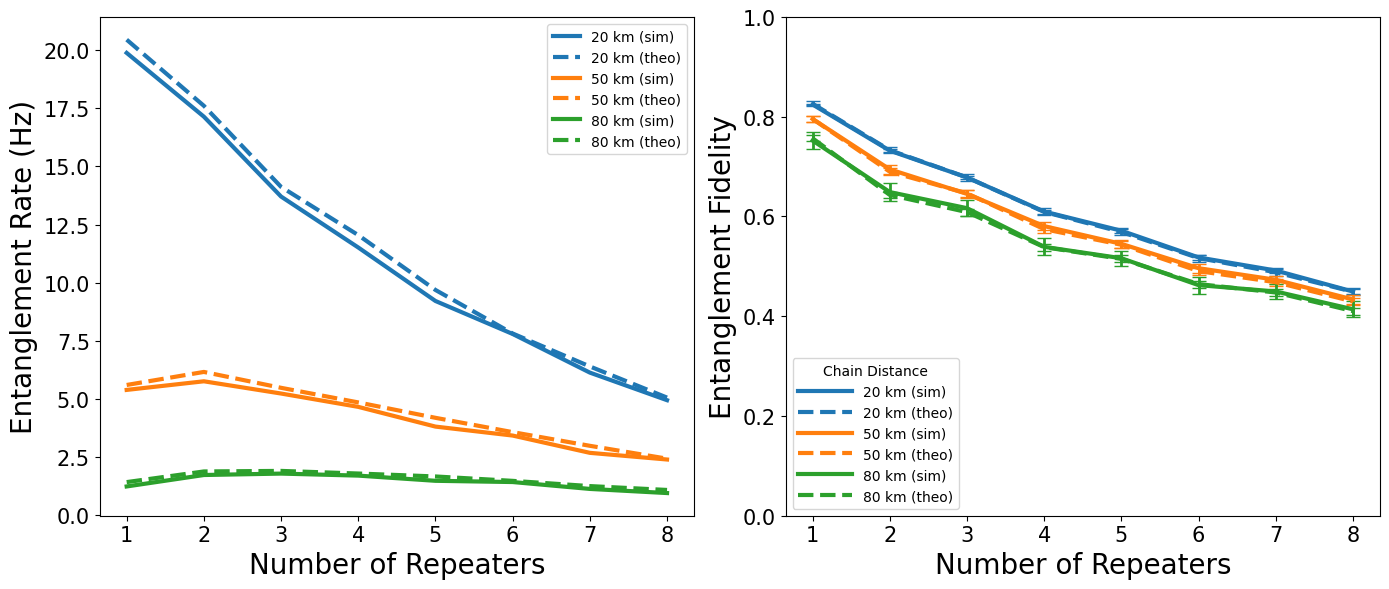

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load both datasets
df_sim = pd.read_csv('results/rate_fid/results_all_distances_repeaters.csv')       # Simulation data
df_theo = pd.read_csv('theo_fidelity_and_success.csv') # Theoretical / alternative data

# Set global plot formatting
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3.0)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

# Distances (use unique values from sim CSV)
distances = sorted(df_sim['distance'].unique())

# Assign colors for distances
colors = ['C0', 'C1', 'C2', 'C3']  # one color per distance
alt_linestyle = '--'               # dotted/dashed for theoretical CSV

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ===== Rate vs Number of Repeaters =====
for i, dist in enumerate(distances):
    subset_sim = df_sim[df_sim['distance'] == dist]
    subset_theo = df_theo[df_theo['distance'] == dist]

    # Simulation (solid line)
    ax[0].plot(subset_sim['num_repeaters'], subset_sim['rate'],
               color=colors[i], linestyle='-', label=f"{dist} km (sim)")
    # Theoretical (dotted line)
    ax[0].plot(subset_theo['num_repeaters'], subset_theo['rate'],
               color=colors[i], linestyle=alt_linestyle, label=f"{dist} km (theo)")

ax[0].set_xlabel("Number of Repeaters")
ax[0].set_ylabel("Entanglement Rate (Hz)")
ax[0].legend(loc='upper right')
# ax[0].set_title("Rate vs Number of Repeaters")

# ===== Fidelity vs Number of Repeaters =====
for i, dist in enumerate(distances):
    subset_sim = df_sim[df_sim['distance'] == dist]
    subset_theo = df_theo[df_theo['distance'] == dist]

    yerr_sim = subset_sim['sem'] if 'sem' in subset_sim.columns else None
    yerr_theo = subset_theo['sem'] if 'sem' in subset_theo.columns else None

    # Simulation
    ax[1].errorbar(subset_sim['num_repeaters'], subset_sim['fidelity'], yerr=yerr_sim,
                   color=colors[i], linestyle='-', capsize=5, elinewidth=2, label=f"{dist} km (sim)")
    # Theoretical
    ax[1].errorbar(subset_theo['num_repeaters'], subset_theo['fidelity'], yerr=yerr_theo,
                   color=colors[i], linestyle=alt_linestyle, capsize=5, elinewidth=2, label=f"{dist} km (theo)")

ax[1].set_xlabel("Number of Repeaters")
ax[1].set_ylabel("Entanglement Fidelity")
ax[1].set_ylim(0, 1)
# Remove duplicate errorbar handles in legend
handles, labels = ax[1].get_legend_handles_labels()
handles = [h[0] for h in handles]
ax[1].legend(handles, labels, loc='lower left', title="Chain Distance", handlelength=3.9)
# ax[1].set_title("Fidelity vs Number of Repeaters")
plt.savefig('repeaters_vs_distance.pdf', format='pdf')
plt.tight_layout()
plt.show()

In [42]:
import pandas as pd

# Load CSV
df = pd.read_csv("ceretry_threshold_sweep.csv")

# Map retries to nearest standard value
def round_retries(x):
    if x <= 45:
        return 30
    elif x <= 75:
        return 60
    elif x <= 105:
        return 90
    else:
        return 120

df['retries'] = df['retries'].apply(round_retries)

# Save back to the same CSV
df.to_csv("ceretry_threshold_sweep.csv", index=False)


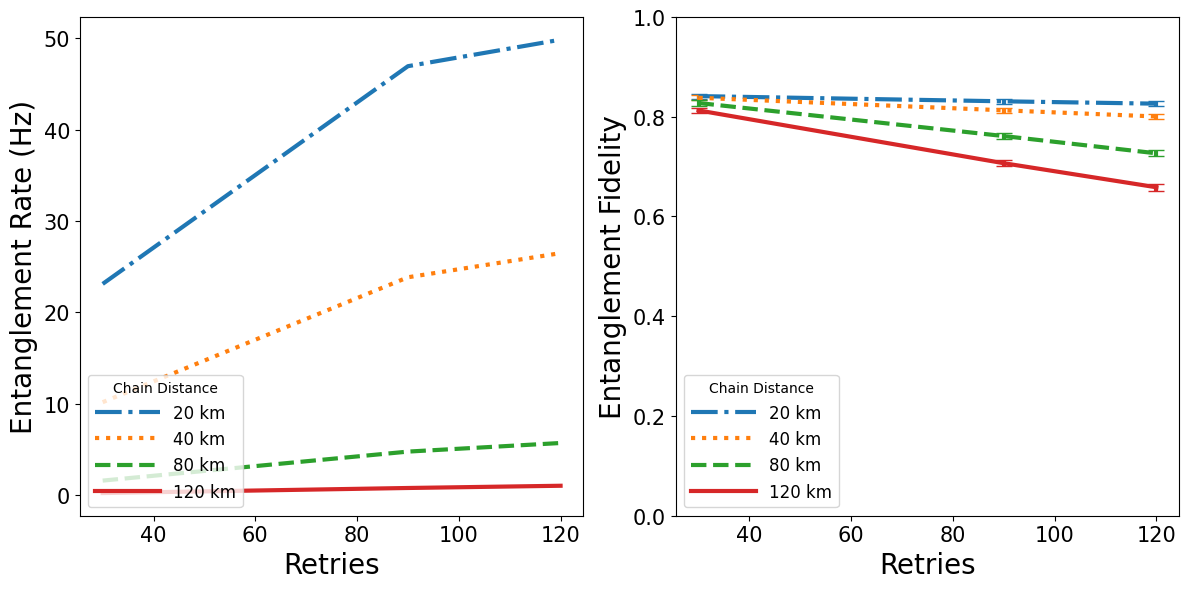

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15)      # Y-axis tick label size

# Define different line styles for retries
line_styles = {80: 'dashed', 120: 'solid', 20: 'dashdot', 40: 'dotted'}
colors = {30: 'black', 90: 'grey', 120: 'dimgrey'}

# List of sets with corresponding CSV file names (the aggregated files)
sets = {
    # "fid_retries": ['fid_retries_agg.csv'],
    "1tr_rate_retries": ['ceretry_threshold_sweep.csv'],
}

# Function to process a single set and plot based on type
def plot_based_on_type(set_name, agg_files, layout='side_by_side'):
    # Load the aggregated CSV file into a DataFrame
    dfs = [pd.read_csv(file) for file in agg_files]
    
    # Concatenate the DataFrames
    merged_df = pd.concat(dfs, ignore_index=True)
    
    # Filter for retries = 30, 90, 120
    filtered_df = merged_df[merged_df['retries'].isin([30, 90, 120])]
    
    # Define subplot layout
    if layout == 'side_by_side':   # Horizontal layout (1 row, 2 columns)
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    else:                          # Vertical layout (2 rows, 1 column)
        fig, ax = plt.subplots(2, 1, figsize=(6, 12))

    # Plot both graphs
    plot_rate_vs_distance(filtered_df, ax[0])
    plot_fid_vs_distance(filtered_df, ax[1])
    handles, labels = ax[1].get_legend_handles_labels()

    # remove the errorbars (only keep line handles)
    handles = [h[0] for h in handles]  # Only keep the lines (remove error bars)

    # use them in the legend
    ax[1].legend(handles, labels, loc='best', title="Chain Distance", prop={'size': 12}, handlelength=3.9)

    # Save and show the plot
    plt.tight_layout()
    plt.savefig('retries_plot.pdf', format='pdf')
    plt.show()

# Plot rate vs distance
def plot_rate_vs_distance(df, ax):
    for dist in [20, 40, 80, 120]:
        subset = df[df['distance'] == dist]
        if not subset.empty:
            ax.plot(subset['retries'], subset['rate'], 
                    label=f'{dist} km', 
                    linestyle=line_styles[dist])
                    # color=colors[retries])
    
    ax.set_xlabel("Retries")
    ax.set_ylabel("Entanglement Rate (Hz)")
    ax.legend(title='Chain Distance',loc="lower left", prop={'size': 12}, handlelength=3.9)
    ax.ticklabel_format(axis='y')

# Plot fidelity vs distance
def plot_fid_vs_distance(df, ax):
    for dist in [20, 40, 80, 120]:
        subset = df[df['distance'] == dist]
        if not subset.empty:
            yerr = subset['sem'].values  # Assuming 'sem' column contains standard error values
            ax.errorbar(subset['retries'], subset['fidelity'], 
                        yerr=yerr,
                        label=f'{dist} km',  # Display scaled distance in the label
                        linestyle=line_styles[dist],capsize=6,
        elinewidth=3)
    
    ax.set_xlabel("Retries")
    ax.set_ylabel("Entanglement Fidelity")
    ax.set_ylim(0, 1)
    ax.legend(title='Chain Distance', loc="lower left", prop={'size': 12}, handlelength=3.9)

# Process each set and plot the graphs
for set_name, files in sets.items():
    plot_based_on_type(set_name, files, layout='side_by_side')  # Change to 'vertical' for stacked layout